In [1]:
import pandas as pd
import numpy as np

df1 = pd.read_excel('/content/Navi Mumbai 6 CAAQMS daily data.xlsx')
df2 = pd.read_excel('/content/Navi Mumbai 6 CAAQMS daily data.xlsx') # Assuming the second dataset is also in the same file, possibly on a different sheet. You may need to adjust this.


df = df1.copy()

df.replace(["NO_DATA", "NA", "Atleast 3 inputs*", "-"], np.nan, inplace=True)

for col in df.columns:
    if col not in ['Date', 'Location']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')           # ensure chronological order in the source data
df = df.set_index('Date')             # makes indexing by time easier later


print("Original data with missing values (first 5 rows):")
print(df.head())
print("\nMissing values count per column:")
print(df.isnull().sum())

FileNotFoundError: [Errno 2] No such file or directory: '/content/Navi Mumbai 6 CAAQMS daily data.xlsx'

# Data cleaning using KNN inputer

In [ ]:
from sklearn.impute import KNNImputer

# We'll select only the numeric columns for imputation, excluding 'Regional Office'
numeric_cols = df.select_dtypes(include=np.number).columns.drop('Regional Office', errors='ignore')
df_numeric = df[numeric_cols]

# Initialize the imputer
# n_neighbors=5 is a good starting point for daily data,
# looking at the 5 most similar days to fill a gap.
knn_imputer = KNNImputer(n_neighbors=5)

# Apply the imputer
df_knn_imputed = pd.DataFrame(knn_imputer.fit_transform(df_numeric), columns=numeric_cols, index=df.index)

print("\nData after KNN Imputation (first 5 rows):")
print(df_knn_imputed.head())
print("\nMissing values count after KNN:")
print(df_knn_imputed.isnull().sum().sum()) # Should be 0


Data after KNN Imputation (first 5 rows):
            Month   Day    Year    PM10    PM25    SO2    NO2    CO     O3  \
Date                                                                         
2022-11-27   11.0  27.0  2022.0  259.33  100.39  25.44  56.61  1.07  38.13   
2022-11-27   11.0  27.0  2022.0  287.52  177.07  12.10  35.69  1.50  28.67   
2022-11-27   11.0  27.0  2022.0  225.60  143.66   5.51  63.64  1.55  43.12   
2022-11-28   11.0  28.0  2022.0   96.25   43.08   6.56  60.80  1.21  20.65   
2022-11-28   11.0  28.0  2022.0  179.48   62.88  29.47  47.43  0.78  26.43   

              NH3  ...    NOx     NO  OXYLENE   RG      SR   TEMP    TOLU  \
Date               ...                                                      
2022-11-27  67.96  ...  56.61   7.80    10.89  0.0   66.30  30.78  198.71   
2022-11-27   7.79  ...  35.69  21.67    15.50  0.0   75.10  28.55    0.65   
2022-11-27  84.00  ...  63.64  37.19    14.44  0.0   84.48  26.82   99.83   
2022-11-28   2.83  ...  6

In [25]:
# Define the features to be used for training the models
features = [col for col in df_knn_imputed.columns if col not in ['AQI', 'Month', 'Day', 'Year']]

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
import xgboost as xgb
import warnings
X = df_knn_imputed[features]
y = df_knn_imputed['AQI']  # Target: AQI

if 'AQI' not in df_knn_imputed.columns:
    raise ValueError("AQI column not found in the data.")

# Combine X and y to drop rows with NaNs consistently
df_combined = pd.concat([X, y], axis=1).dropna()
X = df_combined[features]
y = df_combined['AQI']

# Time-series split: 80% train, 20% test
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Scaling features and target
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_scaled2 = scaler_X.fit_transform(X_train)
X_test_scaled2 = scaler_X.transform(X_test)
y_train_scaled2 = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled2 = scaler_y.transform(y_test.values.reshape(-1, 1))


# Function to evaluate and plot predictions
def evaluate_model(model_name, pred, y_test, y_test_index):
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"\n{model_name} Accuracy Metrics:")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_index, y_test, 'o', color='blue', label='Actual AQI')
    plt.plot(y_test_index, pred.flatten(), 'o', color='orange', label='Predicted AQI')
    plt.title(f'Actual vs Predicted AQI ({model_name})')
    plt.xlabel('Date')
    plt.ylabel('AQI')
    plt.legend()
    plt.show()

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0533
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0108
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0033
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0021
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0017
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0018
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015
Epoch 9/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0016
Epoch 10/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015
Epoch 11/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013
Epoch 12/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014
Epoch 13/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014
Epoch 14/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014
Epoch 15/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014
Epoch 16/50
99/99 ━━━━━━━━━━━━

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

LSTM Accuracy Metrics:
RMSE: 10.97
R² Score: 0.94


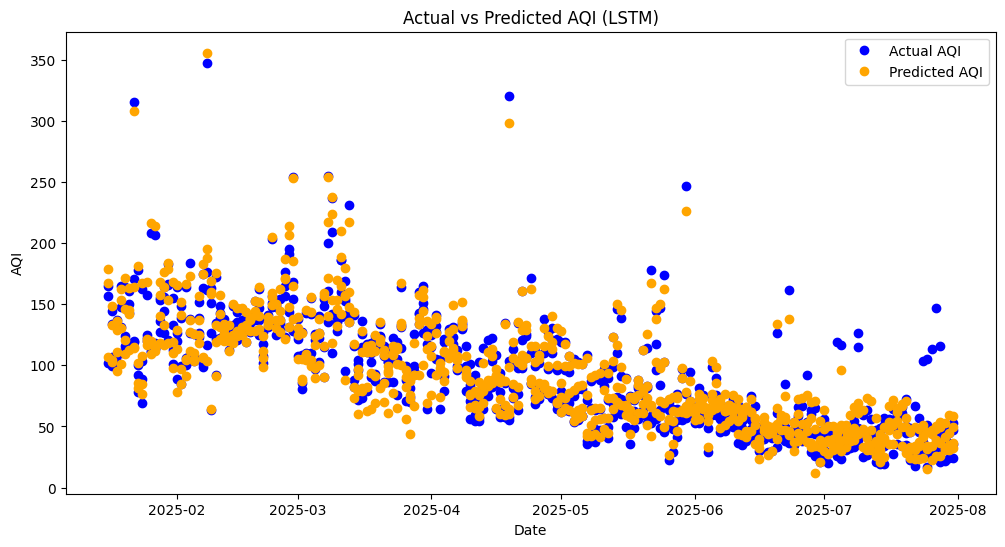

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
import xgboost as xgb
import warnings
X = df_knn_imputed[features]
y = df_knn_imputed['AQI']  # Target: AQI

if 'AQI' not in df_knn_imputed.columns:
    raise ValueError("AQI column not found in the data.")

# Combine X and y to drop rows with NaNs consistently
df_combined = pd.concat([X, y], axis=1).dropna()
X = df_combined[features]
y = df_combined['AQI']

# Time-series split: 80% train, 20% test
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Scaling features and target
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_scaled2 = scaler_X.fit_transform(X_train)
X_test_scaled2 = scaler_X.transform(X_test)
y_train_scaled2 = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled2 = scaler_y.transform(y_test.values.reshape(-1, 1))


# Function to evaluate and plot predictions
def evaluate_model(model_name, pred, y_test, y_test_index):
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"\n{model_name} Accuracy Metrics:")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_index, y_test, 'o', color='blue', label='Actual AQI')
    plt.plot(y_test_index, pred.flatten(), 'o', color='orange', label='Predicted AQI')
    plt.title(f'Actual vs Predicted AQI ({model_name})')
    plt.xlabel('Date')
    plt.ylabel('AQI')
    plt.legend()
    plt.show()

# Model 1: Improved LSTM (with more features)
X_train_lstm = X_train_scaled2.reshape((X_train_scaled2.shape[0], 1, X_train_scaled2.shape[1]))
X_test_lstm = X_test_scaled2.reshape((X_test_scaled2.shape[0], 1, X_test_scaled2.shape[1]))

lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(1, X_train_scaled2.shape[1])))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train_lstm, y_train_scaled2, epochs=50, batch_size=32, verbose=1)

pred_scaled = lstm_model.predict(X_test_lstm)
pred_lstm = scaler_y.inverse_transform(pred_scaled).flatten()
evaluate_model("LSTM", pred_lstm, y_test, y_test.index)


XGBoost Accuracy Metrics:
RMSE: 6.22
R² Score: 0.98


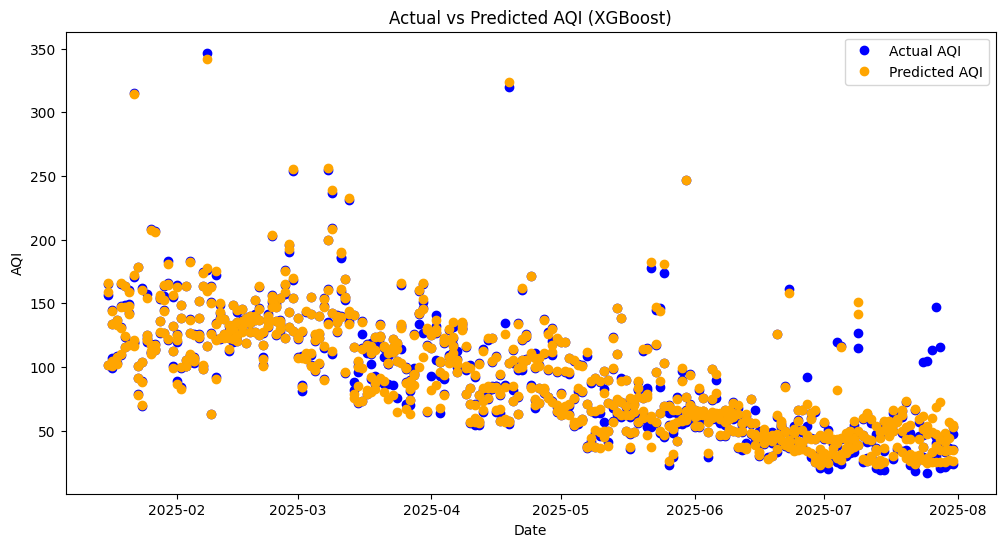

In [28]:
# Model 2: XGBoost (recommended for higher accuracy)
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1]}
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
grid_search = GridSearchCV(xgb_model, param_grid, cv=tscv, scoring='r2')
grid_search.fit(X_train_scaled2, y_train_scaled2.ravel())

best_xgb = grid_search.best_estimator_
pred_scaled = best_xgb.predict(X_test_scaled2)
pred_xgb = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
evaluate_model("XGBoost", pred_xgb, y_test, y_test.index)



Random Forest Accuracy Metrics:
RMSE: 8.16
R² Score: 0.97


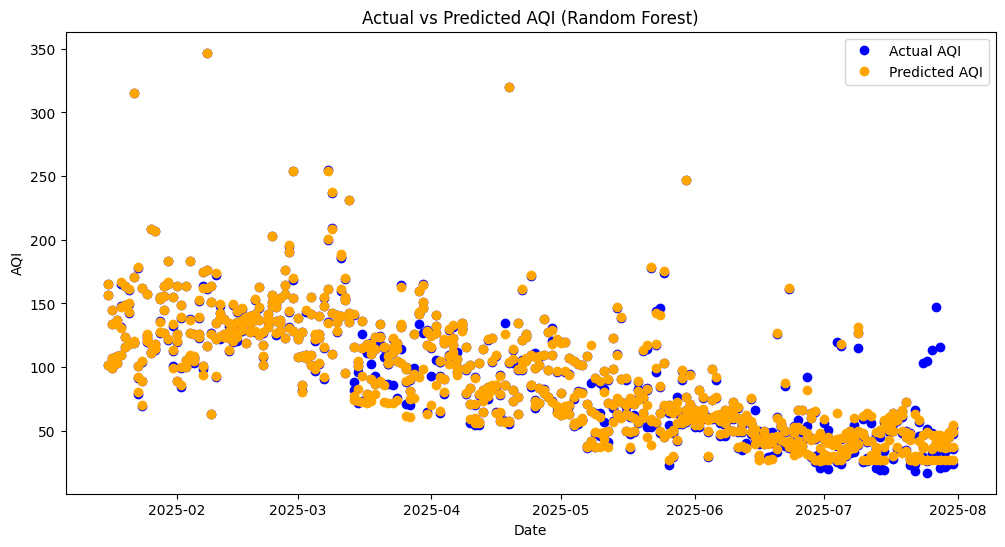

In [29]:
# Model 3: Random Forest
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train_scaled2, y_train_scaled2.ravel())
pred_scaled = rf_model.predict(X_test_scaled2)
pred_rf = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
evaluate_model("Random Forest", pred_rf, y_test, y_test.index)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(



SARIMA Accuracy Metrics:
RMSE: 53.11
R² Score: -0.35


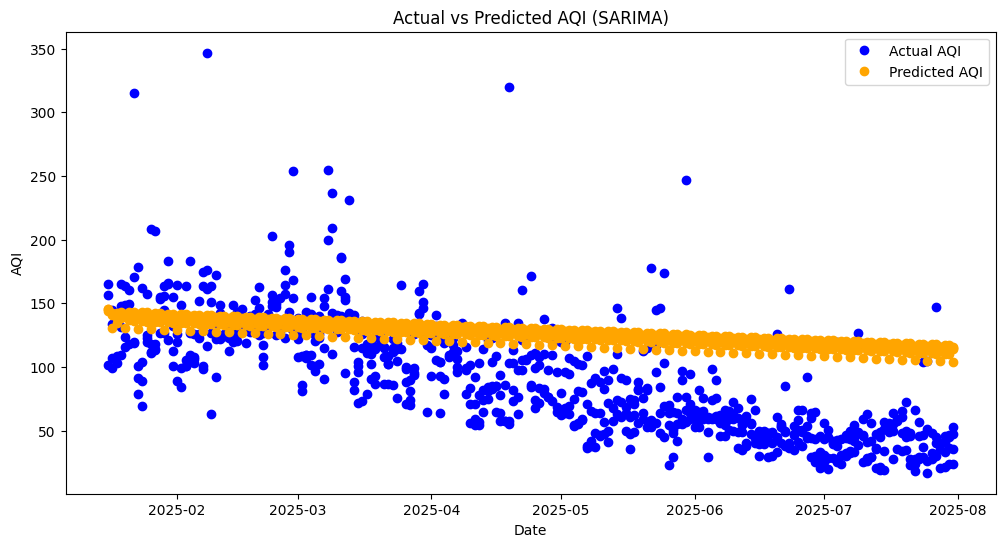


✅ Process Complete: Dataset processed with improvements, models trained, and accuracy metrics reported.


In [30]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Model 4: SARIMA (univariate baseline)
sarima_model = SARIMAX(y_train, order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_fit = sarima_model.fit(disp=False)

# Forecast same length as test
pred_sarima = sarima_fit.forecast(steps=len(y_test))

# Evaluate (convert to numpy for safety)
evaluate_model(
    "SARIMA",
    pred_sarima.values,  # fix here
    y_test.values,       # fix here
    y_test.index
)

print("\n✅ Process Complete: Dataset processed with improvements, models trained, and accuracy metrics reported.")

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



SARIMAX Accuracy Metrics:
RMSE: 19.32
R² Score: 0.82


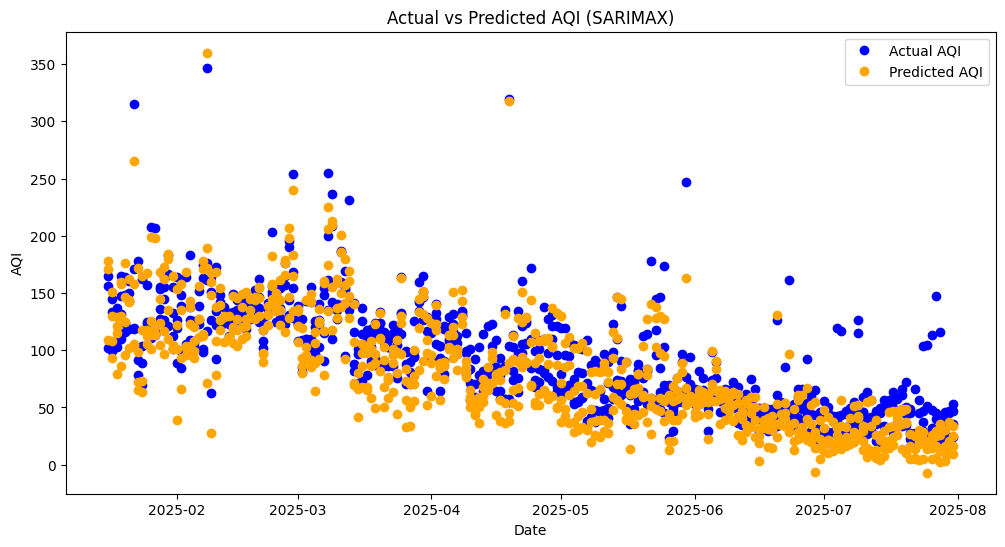

In [32]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Model 5: SARIMAX (captures seasonality)
sarimax_model = SARIMAX(
    y_train_scaled2, # Use scaled y_train
    exog=X_train_scaled2,  # Use scaled X_train
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(disp=False)

# Forecast for the test period
pred_scaled = sarimax_fit.forecast(steps=len(y_test_scaled2), exog=X_test_scaled2) # Use scaled X_test

# ✅ Convert Series → NumPy array before reshaping
pred_scaled_array = pred_scaled.reshape(-1, 1)

# Inverse transform the scaled predictions
pred_sarimax = scaler_y.inverse_transform(pred_scaled_array).flatten()

# Evaluate
evaluate_model("SARIMAX", pred_sarimax, y_test, y_test.index) # Pass the original y_test Series

In [ ]:
from lightgbm import LGBMRegressor

# Model 6: LightGBM
lgb_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_train_scaled2, y_train_scaled2.ravel())

pred_scaled = lgb_model.predict(X_test_scaled2)
pred_lgb = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

evaluate_model("LightGBM", pred_lgb, y_test, y_test.index)



CatBoost Accuracy Metrics:
RMSE: 7.79
R² Score: 0.97


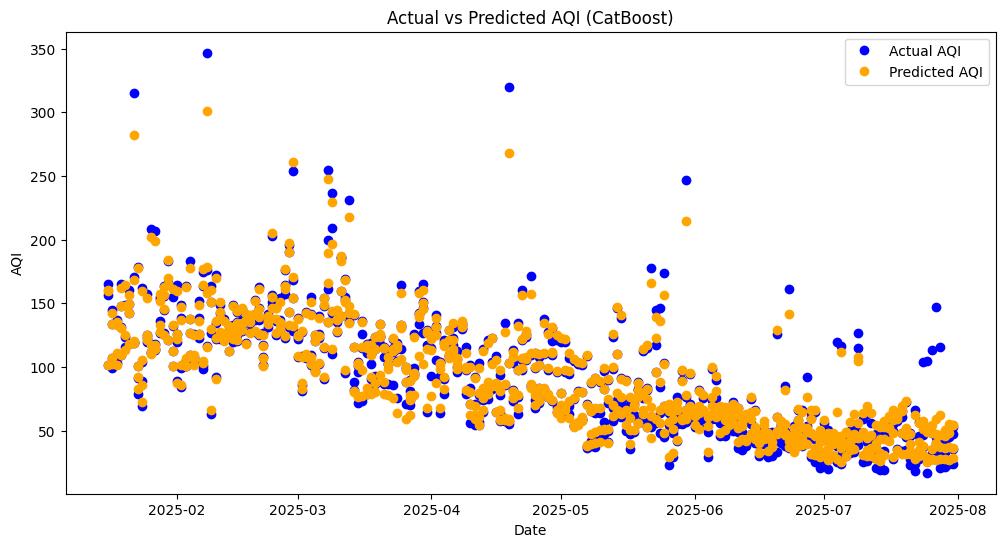

In [22]:
from catboost import CatBoostRegressor

# Model 7: CatBoost
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=10,
    loss_function='RMSE',
    verbose=0,
    random_seed=42
)

cat_model.fit(X_train_scaled2, y_train_scaled2.ravel())

pred_scaled = cat_model.predict(X_test_scaled2)
pred_cat = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

evaluate_model("CatBoost", pred_cat, y_test, y_test.index)


# Data Cleaning using MICE imputer

In [37]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

# We'll select only the numeric columns for imputation, excluding 'Regional Office'
numeric_cols = df.select_dtypes(include=np.number).columns.drop('Regional Office', errors='ignore')
df_numeric = df[numeric_cols]
# Initialize the Iterative Imputer
# We use RandomForestRegressor because it's powerful and can capture non-linear relationships between pollutants.
mice_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10, random_state=0), # A simple RF model
    max_iter=10,  # Number of imputation rounds
    random_state=0
)

# Apply the imputer
df_mice_imputed = pd.DataFrame(mice_imputer.fit_transform(df_numeric), columns=numeric_cols, index=df.index)

print("\nData after MICE Imputation (first 5 rows):")
print(df_mice_imputed.head())
print("\nMissing values count after MICE:")
print(df_mice_imputed.isnull().sum().sum()) # Should be 0


Data after MICE Imputation (first 5 rows):
            Month   Day    Year    PM10    PM25    SO2    NO2    CO     O3  \
Date                                                                         
2022-11-27   11.0  27.0  2022.0  259.33  100.39  25.44  56.61  1.07  38.13   
2022-11-27   11.0  27.0  2022.0  287.52  177.07  12.10  35.69  1.50  28.67   
2022-11-27   11.0  27.0  2022.0  225.60  143.66   5.51  63.64  1.55  43.12   
2022-11-28   11.0  28.0  2022.0   96.25   43.08   6.56  60.80  1.21  20.65   
2022-11-28   11.0  28.0  2022.0  179.48   62.88  29.47  47.43  0.78  26.43   

              NH3  ...    NOx     NO  OXYLENE   RG      SR   TEMP    TOLU  \
Date               ...                                                      
2022-11-27  67.96  ...  56.61   7.80    10.89  0.0   66.30  30.78  198.71   
2022-11-27   7.79  ...  35.69  21.67    15.50  0.0   75.10  28.55    0.65   
2022-11-27  84.00  ...  63.64  37.19    14.44  0.0   84.48  26.82   99.83   
2022-11-28   2.83  ...  

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [38]:
# Define the features to be used for training the models
features = [col for col in df_mice_imputed.columns if col not in ['AQI', 'Month', 'Day', 'Year']]

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
import xgboost as xgb
import warnings
X = df_mice_imputed[features]
y = df_mice_imputed['AQI']  # Target: AQI

if 'AQI' not in df_mice_imputed.columns:
    raise ValueError("AQI column not found in the data.")

# Combine X and y to drop rows with NaNs consistently
df_combined = pd.concat([X, y], axis=1).dropna()
X = df_combined[features]
y = df_combined['AQI']

# Time-series split: 80% train, 20% test
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Scaling features and target
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))


# Function to evaluate and plot predictions
def evaluate_model(model_name, pred, y_test, y_test_index):
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"\n{model_name} Accuracy Metrics:")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_index, y_test, 'o', color='blue', label='Actual AQI')
    plt.plot(y_test_index, pred.flatten(), 'o', color='orange', label='Predicted AQI')
    plt.title(f'Actual vs Predicted AQI ({model_name})')
    plt.xlabel('Date')
    plt.ylabel('AQI')
    plt.legend()
    plt.show()

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0498
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0113
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0033
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0018
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0017
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0017
Epoch 9/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0016
Epoch 10/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0015
Epoch 11/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0016
Epoch 12/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015
Epoch 13/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013
Epoch 14/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0014
Epoch 15/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014
Epoch 16/50
99/99 ━━━━━━━━━━━━

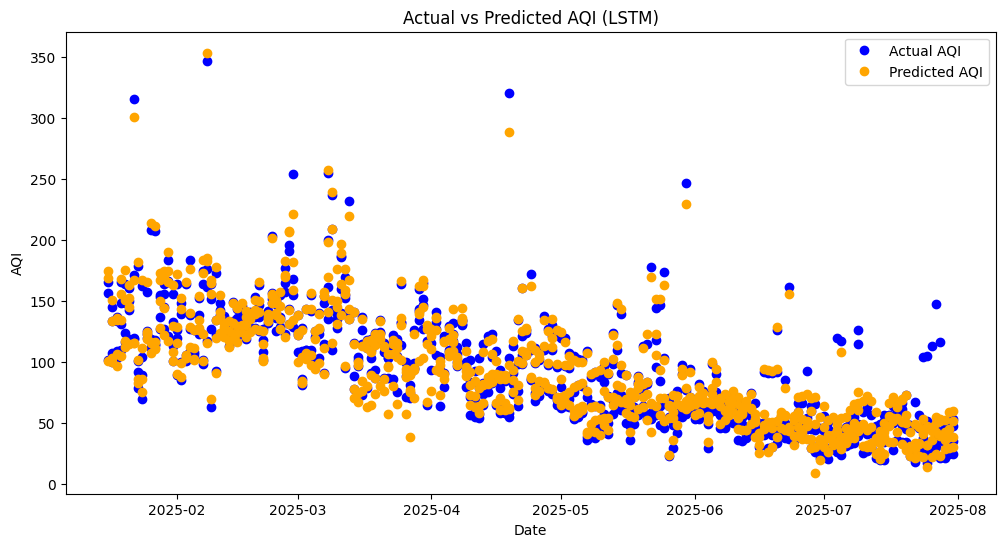

In [40]:
# Model 1: Improved LSTM (with more features)
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(1, X_train_scaled.shape[1])))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train_lstm, y_train_scaled, epochs=50, batch_size=32, verbose=1)

pred_scaled = lstm_model.predict(X_test_lstm)
pred_lstm = scaler_y.inverse_transform(pred_scaled).flatten()
evaluate_model("LSTM", pred_lstm, y_test, y_test.index)




XGBoost Accuracy Metrics:
RMSE: 6.42
R² Score: 0.98


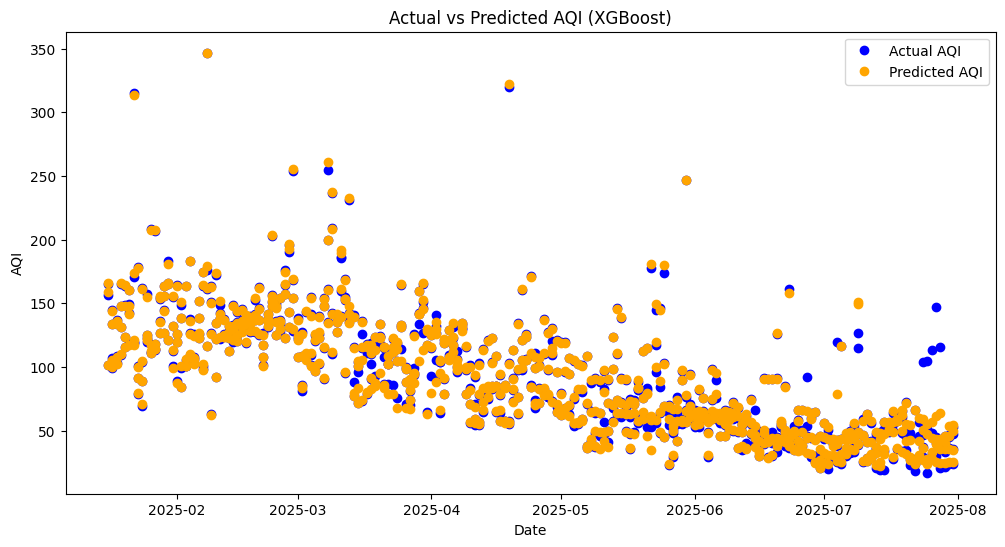

In [41]:
# Model 2: XGBoost (recommended for higher accuracy)
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1]}
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
grid_search = GridSearchCV(xgb_model, param_grid, cv=tscv, scoring='r2')
grid_search.fit(X_train_scaled, y_train_scaled.ravel())

best_xgb = grid_search.best_estimator_
pred_scaled = best_xgb.predict(X_test_scaled)
pred_xgb = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
evaluate_model("XGBoost", pred_xgb, y_test, y_test.index)



Random Forest Accuracy Metrics:
RMSE: 8.07
R² Score: 0.97


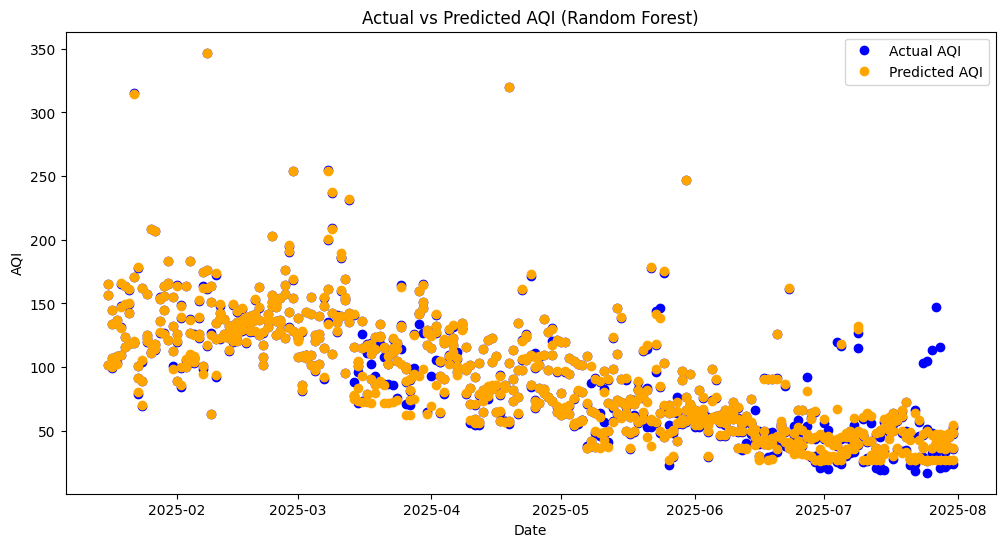

In [42]:
# Model 3: Random Forest
rf_model = RandomForestRegressor(n_estimators=500, max_depth=10, random_state=42)
rf_model.fit(X_train_scaled, y_train_scaled.ravel())
pred_scaled = rf_model.predict(X_test_scaled)
pred_rf = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
evaluate_model("Random Forest", pred_rf, y_test, y_test.index)



SARIMA Accuracy Metrics:
RMSE: 88.43
R² Score: -2.75


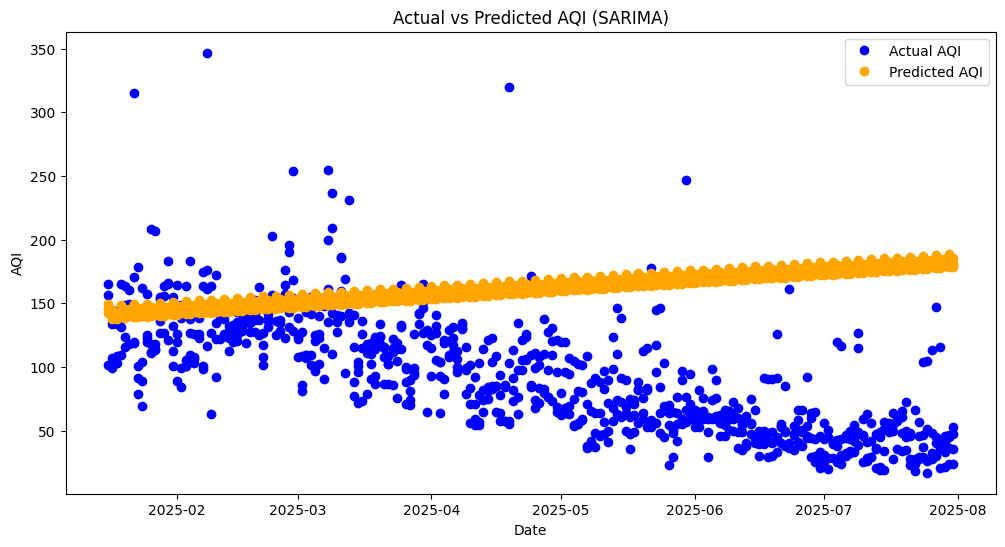


✅ Process Complete: Dataset processed with improvements, models trained, and accuracy metrics reported.


In [43]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Model 4: SARIMA (univariate baseline)
sarima_model = SARIMAX(y_train_scaled, order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_fit = sarima_model.fit(disp=False)

# Forecast same length as test
pred_sarima = sarima_fit.forecast(steps=len(y_test_scaled))

# Evaluate (convert to numpy for safety)
evaluate_model(
    "SARIMA",
    scaler_y.inverse_transform(pred_sarima.reshape(-1, 1)).flatten(),  # Inverse scale the predictions
    y_test,       # Pass the original y_test Series
    y_test.index
)

print("\n✅ Process Complete: Dataset processed with improvements, models trained, and accuracy metrics reported.")

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



SARIMAX Accuracy Metrics:
RMSE: 18.87
R² Score: 0.83


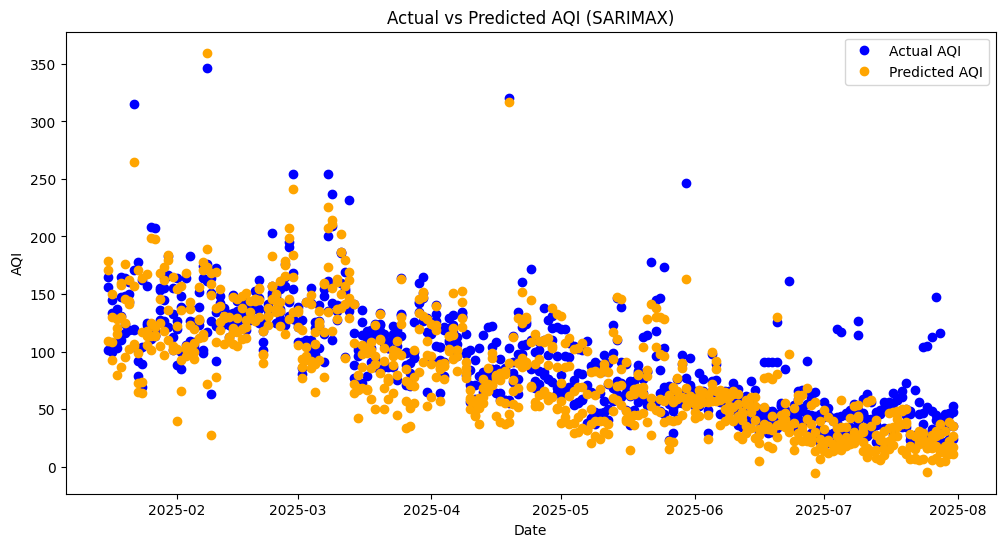

In [44]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Model 5: SARIMAX (captures seasonality)
sarimax_model = SARIMAX(
    y_train_scaled, # Use scaled y_train
    exog=X_train_scaled,  # Use scaled X_train
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(disp=False)

# Forecast for the test period
pred_scaled = sarimax_fit.forecast(steps=len(y_test_scaled), exog=X_test_scaled) # Use scaled X_test

# ✅ Convert Series → NumPy array before reshaping
pred_scaled_array = pred_scaled.reshape(-1, 1)

# Inverse transform the scaled predictions
pred_sarimax = scaler_y.inverse_transform(pred_scaled_array).flatten()

# Evaluate
evaluate_model("SARIMAX", pred_sarimax, y_test, y_test.index) # Pass the original y_test Series

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000775 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5073
[LightGBM] [Info] Number of data points in the train set: 3144, number of used features: 20
[LightGBM] [Info] Start training from score 0.254034
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



LightGBM Accuracy Metrics:
RMSE: 7.31
R² Score: 0.97


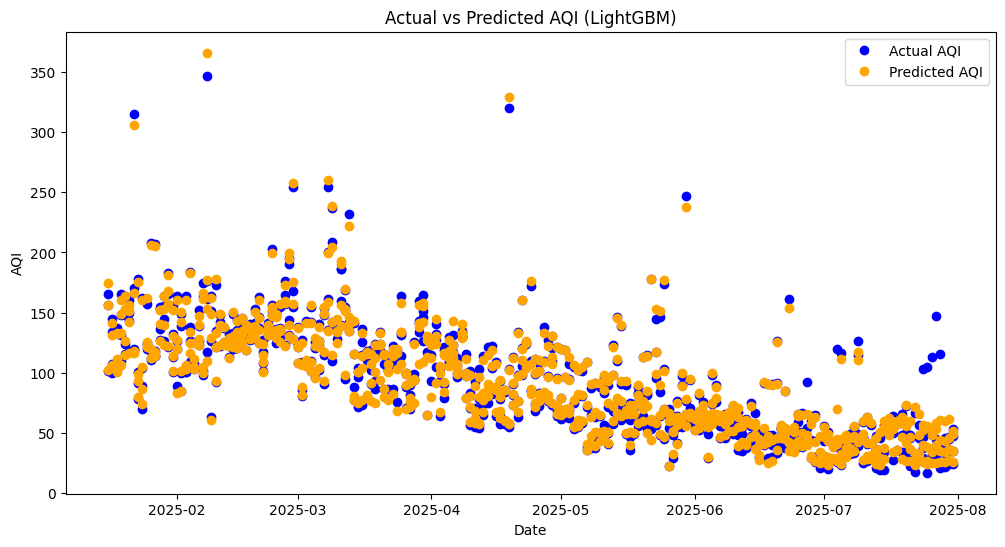

In [47]:
from lightgbm import LGBMRegressor

# Model 6: LightGBM
lgb_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_train_scaled, y_train_scaled.ravel())

pred_scaled = lgb_model.predict(X_test_scaled)
pred_lgb = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

evaluate_model("LightGBM", pred_lgb, y_test, y_test.index)


In [45]:
%pip install catboost


CatBoost Accuracy Metrics:
RMSE: 7.71
R² Score: 0.97


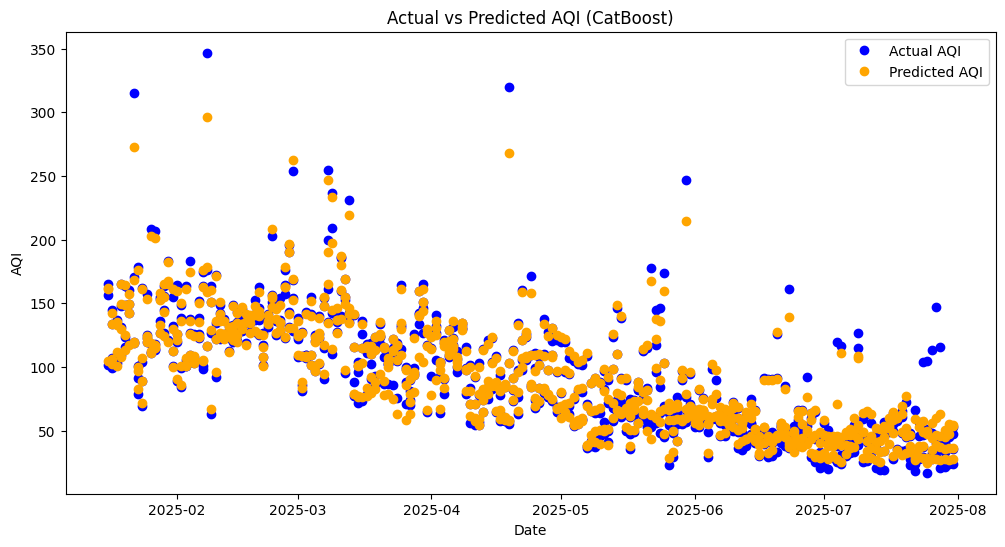

In [46]:
from catboost import CatBoostRegressor

# Model 7: CatBoost
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=10,
    loss_function='RMSE',
    verbose=0,
    random_seed=42
)

cat_model.fit(X_train_scaled, y_train_scaled.ravel())

pred_scaled = cat_model.predict(X_test_scaled)
pred_cat = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

evaluate_model("CatBoost", pred_cat, y_test, y_test.index)


# Data Cleaning using IDW imputer

In [48]:
# --- Actual Coordinates for Navi Mumbai Stations ---
# These have been updated with real geographical data.
station_coords = {
    "Navi Mumbai, Mahape": (19.12, 73.03),
    "Navi Mumbai, Nerul": (19.03, 73.02),
    "Navi Mumbai, Belapur": (19.02, 73.04),
    "Navi Mumbai, Vashi": (19.08, 73.01),
    "Navi Mumbai, Sanpada": (19.06, 73.01),
    "Navi Mumbai, Taloja": (19.08, 73.08)
}

In [49]:
import numpy as np

def idw_impute(df, target_station, target_column, station_coords, station_mapping, p=2):
    """
    Imputes a missing value for a target station using IDW from other stations.
    Note: This is a simplified version for demonstration.
    """
    # Separate the target station's data from the others
    df_target = df[df['Location'] == target_station].copy()
    df_others = df[df['Location'] != target_station].copy()

    imputed_values = []
    target_station_coord_key = station_mapping.get(target_station)

    if target_station_coord_key is None:
        # If target station is not in mapping, return original values
        return df_target

    target_coord = station_coords[target_station_coord_key]


    for index, row in df_target.iterrows():
        if pd.isnull(row[target_column]):
            # Get data from other stations at the same timestamp
            timestamp_data = df_others.loc[index]

            # Calculate distances and weights
            distances = []
            values = []

            # Check if timestamp_data is a DataFrame or a Series
            if isinstance(timestamp_data, pd.Series):
                # Handle case where only one other station has data at this timestamp
                other_station = timestamp_data['Location']
                other_station_coord_key = station_mapping.get(other_station)
                if other_station_coord_key is not None and not pd.isnull(timestamp_data[target_column]):
                    other_coord = station_coords[other_station_coord_key]
                    # Simple Euclidean distance
                    dist = np.sqrt((target_coord[0] - other_coord[0])**2 + (target_coord[1] - other_coord[1])**2)
                    if dist > 0:
                        distances.append(dist)
                        values.append(timestamp_data[target_column])
            else:
                # Handle case where multiple other stations have data at this timestamp
                for _, other_row in timestamp_data.iterrows():
                    other_station = other_row['Location']
                    other_station_coord_key = station_mapping.get(other_station)
                    if other_station_coord_key is not None and not pd.isnull(other_row[target_column]):
                        other_coord = station_coords[other_station_coord_key]
                        # Simple Euclidean distance
                        dist = np.sqrt((target_coord[0] - other_coord[0])**2 + (target_coord[1] - other_coord[1])**2)
                        if dist > 0:
                            distances.append(dist)
                            values.append(other_row[target_column])


            if not values: # If no other stations have data
                imputed_values.append(np.nan)
                continue

            weights = 1 / (np.array(distances) ** p)
            weighted_avg = np.sum(weights * values) / np.sum(weights)
            imputed_values.append(weighted_avg)
        else:
            imputed_values.append(row[target_column])

    df_target[f'{target_column}_idw_imputed'] = imputed_values
    return df_target

# Example: Impute PM2.5 for the Mahape station
# You would need to run this for each station and each column with missing data
# A full implementation would require a more robust loop structure.
# This example requires a combined dataframe with the 'Location' column.
# Let's use the existing 'df' dataframe for this demonstration.

# Note: The IDW function is a basic example. For a large dataset, this would be slow.
print("\nApplying IDW (this may be slow)...")
# First, make sure the 'Location' column is available in the dataframe used for IDW
# The initial 'df' dataframe from cell 6sLWXvciWe09 has the 'Location' column
df_combined_for_idw = df.copy()

# Rename the 'Date' index to 'DateTime' to match the original example's expectation
df_combined_for_idw.index.name = 'DateTime'

# Create a mapping from dataframe station names to station_coords keys
station_mapping = {
    'Belapur': 'Navi Mumbai, Belapur',
    'Koprigaon Vashi': 'Navi Mumbai, Vashi', # Assuming 'Koprigaon Vashi' maps to 'Navi Mumbai, Vashi'
    'Sanpada': 'Navi Mumbai, Sanpada',
    'Taloja': 'Navi Mumbai, Taloja',
    'belapur': 'Navi Mumbai, Belapur' # Assuming 'belapur' maps to 'Navi Mumbai, Belapur'
}

# Now apply the IDW imputation using the existing 'df_combined_for_idw' dataframe
df_mahape_imputed = idw_impute(df_combined_for_idw, 'Belapur', 'PM25', station_coords, station_mapping)

print("\nData after IDW Imputation for Belapur PM2.5 (first 5 rows with imputed column):")
print(df_mahape_imputed.head())


Applying IDW (this may be slow)...

Data after IDW Imputation for Belapur PM2.5 (first 5 rows with imputed column):
            Month   Day  Year Location  Regional Office    PM10   PM25    SO2  \
DateTime                                                                        
2022-11-28     11  28.0  2022  Belapur              NaN   96.25  43.08   6.56   
2022-11-29     11  29.0  2022  Belapur              NaN  150.99  64.11  15.85   
2022-11-30     11  30.0  2022  Belapur              NaN  188.77  90.66  11.91   
2022-12-01     12   1.0  2022  Belapur              NaN  169.99  87.43  13.69   
2022-12-02     12   2.0  2022  Belapur              NaN  191.14  94.34  14.78   

               NO2    CO  ...     NO  OXYLENE   RG     SR   TEMP   TOLU  \
DateTime                  ...                                             
2022-11-28   60.80  1.21  ...  11.56     3.64  0.0  110.3  29.02  51.39   
2022-11-29  101.57  1.45  ...  36.60     6.28  0.0  102.9  27.71  34.65   
2022-11-30   86

In [50]:
# Identify columns with missing values (excluding 'Regional Office' and 'Location')
cols_to_impute_idw = df_combined_for_idw.columns[df_combined_for_idw.isnull().any()].tolist()
cols_to_impute_idw = [col for col in cols_to_impute_idw if col not in ['Regional Office', 'Location', 'Month', 'Day', 'Year']] # Exclude date components and non-numeric columns

# Get unique station names from the dataframe
stations = df_combined_for_idw['Location'].unique().tolist()

# Create a mapping from dataframe station names to station_coords keys
station_mapping = {
    'Belapur': 'Navi Mumbai, Belapur',
    'Koprigaon Vashi': 'Navi Mumbai, Vashi', # Assuming 'Koprigaon Vashi' maps to 'Navi Mumbai, Vashi'
    'Sanpada': 'Navi Mumbai, Sanpada',
    'Taloja': 'Navi Mumbai, Taloja',
    'belapur': 'Navi Mumbai, Belapur' # Assuming 'belapur' maps to 'Navi Mumbai, Belapur'
}


# Create a copy of the original dataframe to store the IDW imputed values
df_idw_imputed_full = df_combined_for_idw.copy()

print(f"\nApplying IDW imputation for columns: {cols_to_impute_idw} across stations: {stations}")

# Iterate through each station and each column to impute
for station in stations:
    print(f"Imputing for station: {station}")
    # Get the corresponding key from station_coords
    station_coord_key = station_mapping.get(station)

    if station_coord_key is None:
        print(f"  Skipping station {station} as no mapping found in station_coords.")
        continue

    for col in cols_to_impute_idw:
        print(f"  Imputing column: {col}")
        # Apply the idw_impute function, passing the station_mapping
        df_imputed_col = idw_impute(df_combined_for_idw, station, col, station_coords, station_mapping)

        # Update the original dataframe with the imputed values for the current station and column
        # Use .loc to select the specific station and update the original column directly
        df_idw_imputed_full.loc[df_idw_imputed_full['Location'] == station, col] = df_imputed_col[f'{col}_idw_imputed']


print("\nMissing values count after full IDW imputation:")
print(df_idw_imputed_full.isnull().sum())

# You might want to save this imputed dataframe or continue with further analysis
# print("\nFull dataframe after IDW imputation (first 5 rows):")
# display(df_idw_imputed_full.head())


Applying IDW imputation for columns: ['PM10', 'PM25', 'SO2', 'NO2', 'CO', 'O3', 'NH3', 'BENZ', 'ETHBENZ', 'HUM', 'MPXYL', 'NOx', 'NO', 'OXYLENE', 'RG', 'SR', 'TEMP', 'TOLU', 'WD', 'WS', 'AQI'] across stations: ['Taloja', 'Sanpada', 'Koprigaon Vashi', 'Belapur', 'belapur']
Imputing for station: Taloja
  Imputing column: PM10
  Imputing column: PM25
  Imputing column: SO2
  Imputing column: NO2
  Imputing column: CO
  Imputing column: O3
  Imputing column: NH3
  Imputing column: BENZ
  Imputing column: ETHBENZ
  Imputing column: HUM
  Imputing column: MPXYL
  Imputing column: NOx
  Imputing column: NO
  Imputing column: OXYLENE
  Imputing column: RG
  Imputing column: SR
  Imputing column: TEMP
  Imputing column: TOLU
  Imputing column: WD
  Imputing column: WS
  Imputing column: AQI
Imputing for station: Sanpada
  Imputing column: PM10
  Imputing column: PM25
  Imputing column: SO2
  Imputing column: NO2
  Imputing column: CO
  Imputing column: O3
  Imputing column: NH3
  Imputing colu

In [51]:
# Define the features to be used for training the models
features = [col for col in df_idw_imputed_full.columns if col not in ['AQI', 'Month', 'Day', 'Year', 'Regional Office', 'Location']]

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
import xgboost as xgb
import warnings
X = df_idw_imputed_full[features]
y = df_idw_imputed_full['AQI']  # Target: AQI

if 'AQI' not in df_idw_imputed_full.columns:
    raise ValueError("AQI column not found in the data.")

# Combine X and y to drop rows with NaNs consistently
# df_combined = pd.concat([X, y], axis=1).dropna() # Removed dropna()
# X = df_combined[features] # Updated to use X and y directly
# y = df_combined['AQI'] # Updated to use X and y directly

# Time-series split: 80% train, 20% test
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Scaling features and target
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_scaled1 = scaler_X.fit_transform(X_train)
X_test_scaled1 = scaler_X.transform(X_test)
y_train_scaled1 = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled1 = scaler_y.transform(y_test.values.reshape(-1, 1))


# Function to evaluate and plot predictions
def evaluate_model(model_name, pred, y_test, y_test_index):
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"\n{model_name} Accuracy Metrics:")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_index, y_test, 'o', color='blue', label='Actual AQI')
    plt.plot(y_test_index, pred.flatten(), 'o', color='orange', label='Predicted AQI')
    plt.title(f'Actual vs Predicted AQI ({model_name})')
    plt.xlabel('Date')
    plt.ylabel('AQI')
    plt.legend()
    plt.show()

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0479
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0083
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0030
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0025
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0023
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0024
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0019
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0020
Epoch 9/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0019
Epoch 10/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0019
Epoch 11/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0020
Epoch 12/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0018
Epoch 13/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0018
Epoch 14/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0017
Epoch 15/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0016
Epoch 16/50
99/99 ━━━━━━━━━━━

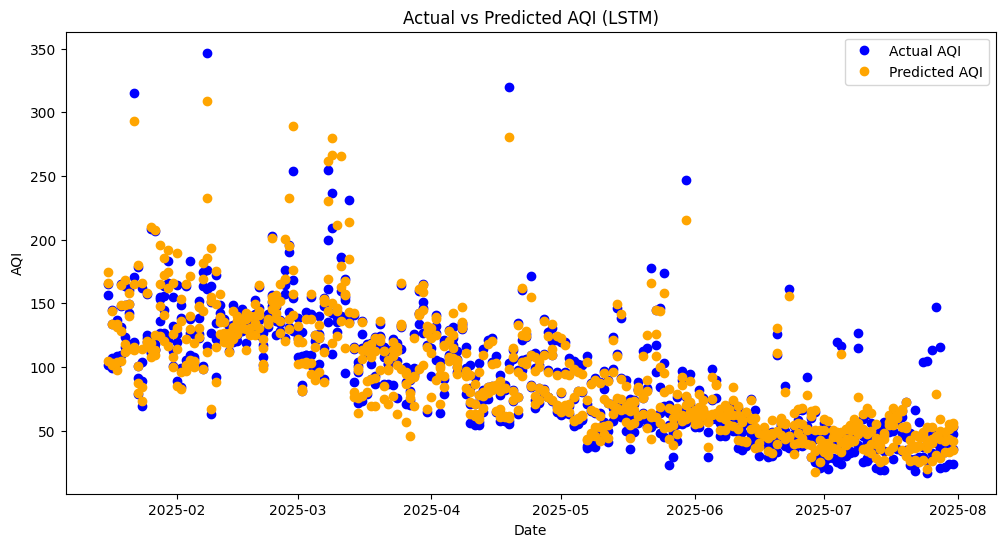

In [53]:
# Model 1: Improved LSTM (with more features)
X_train_lstm = X_train_scaled1.reshape((X_train_scaled1.shape[0], 1, X_train_scaled1.shape[1]))
X_test_lstm = X_test_scaled1.reshape((X_test_scaled1.shape[0], 1, X_test_scaled1.shape[1]))

lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(1, X_train_scaled.shape[1])))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train_lstm, y_train_scaled, epochs=50, batch_size=32, verbose=1)

pred_scaled = lstm_model.predict(X_test_lstm)
pred_lstm = scaler_y.inverse_transform(pred_scaled).flatten()
evaluate_model("LSTM", pred_lstm, y_test, y_test.index)


XGBoost Accuracy Metrics:
RMSE: 6.75
R² Score: 0.98


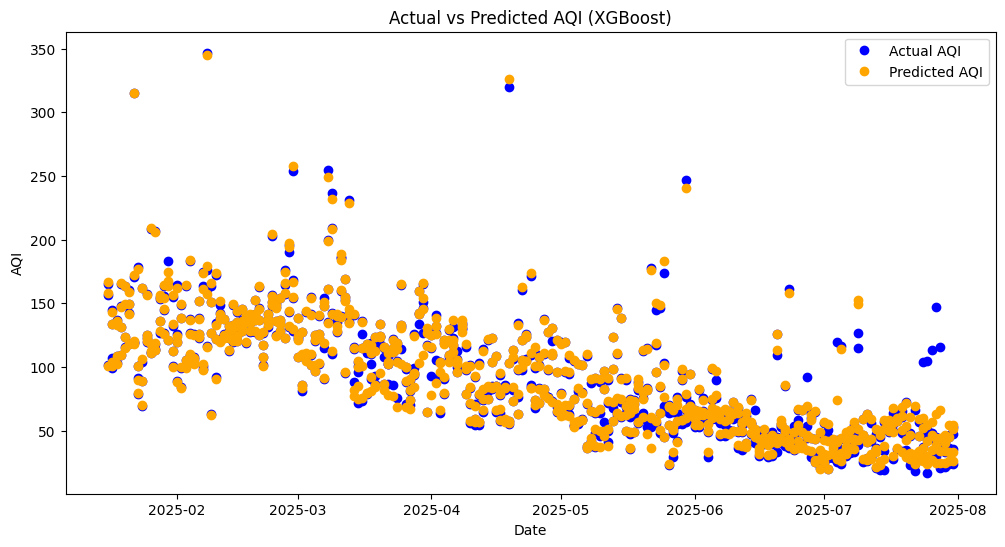

In [54]:
# Model 2: XGBoost (recommended for higher accuracy)
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1]}
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
grid_search = GridSearchCV(xgb_model, param_grid, cv=tscv, scoring='r2')
grid_search.fit(X_train_scaled1, y_train_scaled1.ravel())

best_xgb = grid_search.best_estimator_
pred_scaled = best_xgb.predict(X_test_scaled1)
pred_xgb = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
evaluate_model("XGBoost", pred_xgb, y_test, y_test.index)



Random Forest Accuracy Metrics:
RMSE: 8.24
R² Score: 0.97


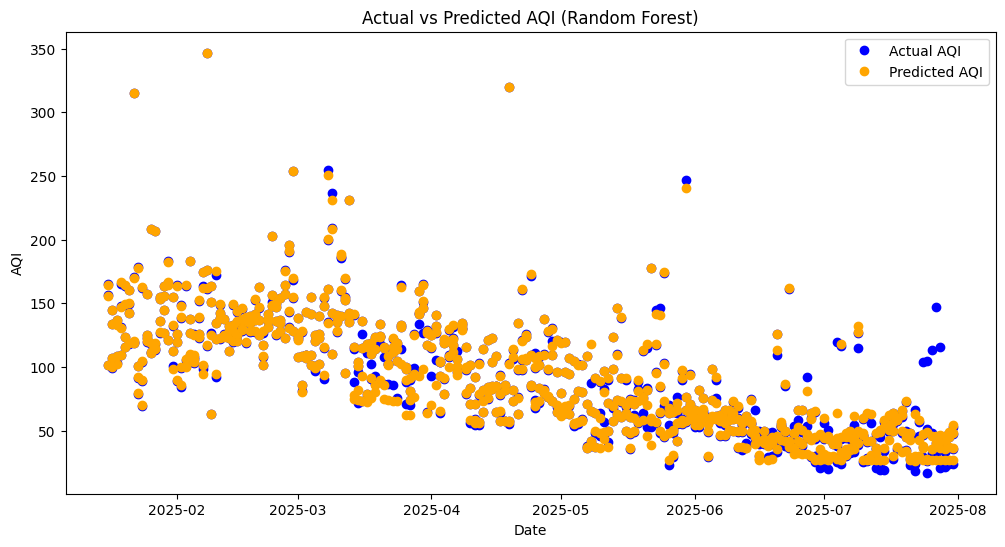

In [55]:
# Model 3: Random Forest
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train_scaled1, y_train_scaled1.ravel())
pred_scaled = rf_model.predict(X_test_scaled1)
pred_rf = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
evaluate_model("Random Forest", pred_rf, y_test, y_test.index)


SARIMA Accuracy Metrics:
RMSE: 77.78
R² Score: -1.89


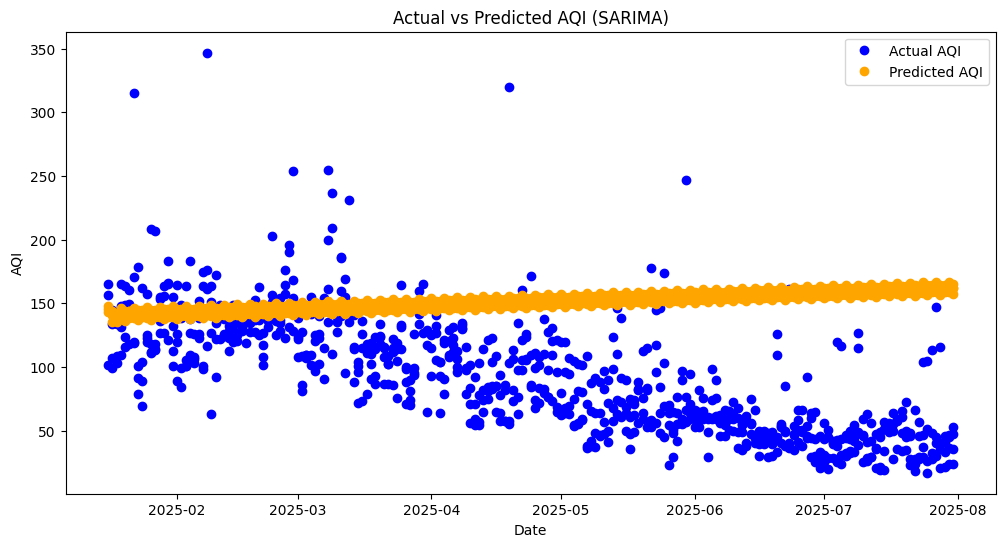


✅ Process Complete: Dataset processed with improvements, models trained, and accuracy metrics reported.


In [56]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Model 4: SARIMA (univariate baseline)
sarima_model = SARIMAX(y_train_scaled1, order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_fit = sarima_model.fit(disp=False)

# Forecast same length as test
pred_sarima = sarima_fit.forecast(steps=len(y_test_scaled))

# Evaluate (convert to numpy for safety)
evaluate_model(
    "SARIMA",
    scaler_y.inverse_transform(pred_sarima.reshape(-1, 1)).flatten(),  # Inverse scale the predictions
    y_test,       # Pass the original y_test Series
    y_test.index
)

print("\n✅ Process Complete: Dataset processed with improvements, models trained, and accuracy metrics reported.")

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



SARIMAX Accuracy Metrics:
RMSE: 18.97
R² Score: 0.83


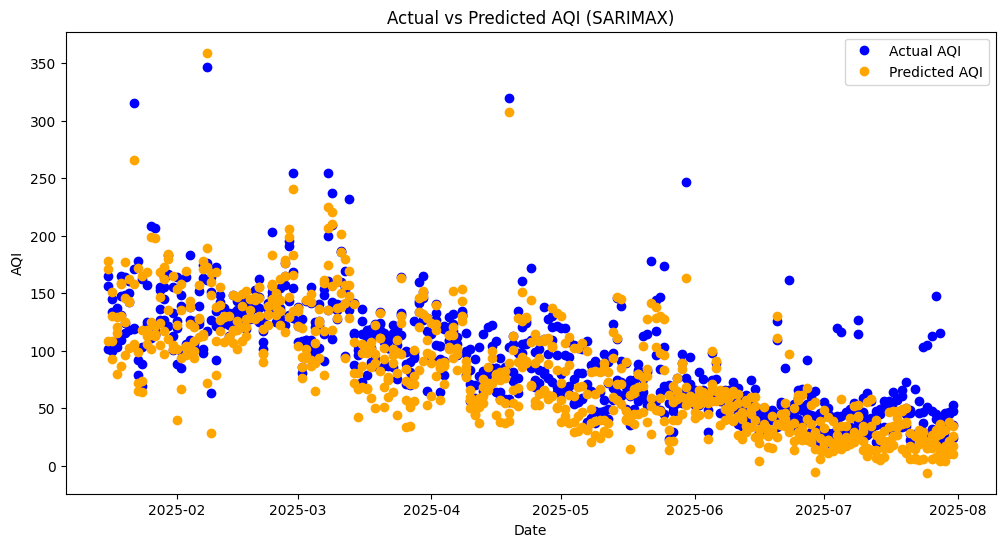

In [57]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Model 5: SARIMAX (captures seasonality)
sarimax_model = SARIMAX(
    y_train_scaled1, # Use scaled y_train
    exog=X_train_scaled1,  # Use scaled X_train
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(disp=False)

# Forecast for the test period
pred_scaled = sarimax_fit.forecast(steps=len(y_test_scaled1), exog=X_test_scaled1) # Use scaled X_test

# ✅ Convert Series → NumPy array before reshaping
pred_scaled_array = pred_scaled.reshape(-1, 1)

# Inverse transform the scaled predictions
pred_sarimax = scaler_y.inverse_transform(pred_scaled_array).flatten()

# Evaluate
evaluate_model("SARIMAX", pred_sarimax, y_test, y_test.index) # Pass the original y_test Series

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000711 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5078
[LightGBM] [Info] Number of data points in the train set: 3144, number of used features: 20
[LightGBM] [Info] Start training from score 0.254034
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



LightGBM Accuracy Metrics:
RMSE: 8.43
R² Score: 0.97


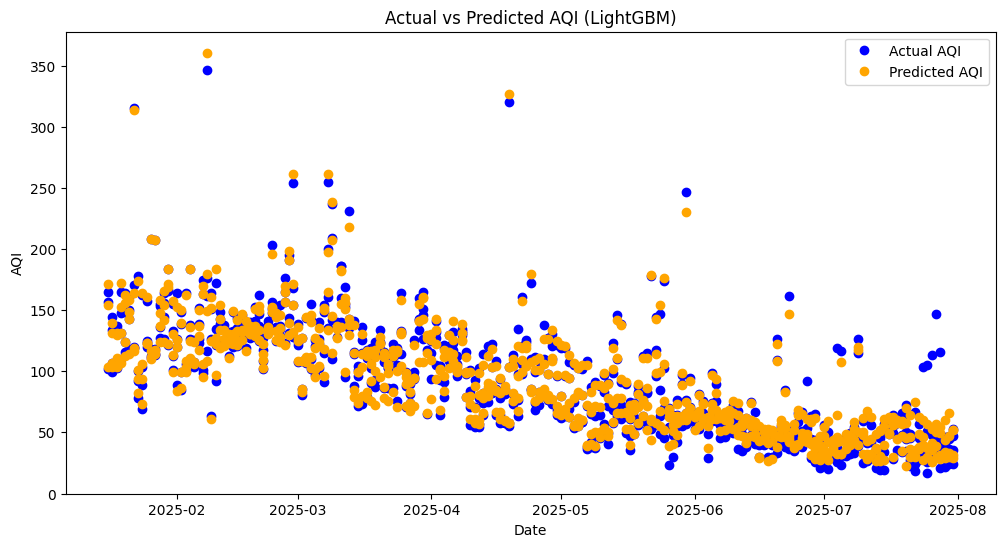

In [58]:
from lightgbm import LGBMRegressor

# Model 6: LightGBM
lgb_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_train_scaled1, y_train_scaled.ravel())

pred_scaled = lgb_model.predict(X_test_scaled1)
pred_lgb = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

evaluate_model("LightGBM", pred_lgb, y_test, y_test.index)



CatBoost Accuracy Metrics:
RMSE: 8.11
R² Score: 0.97


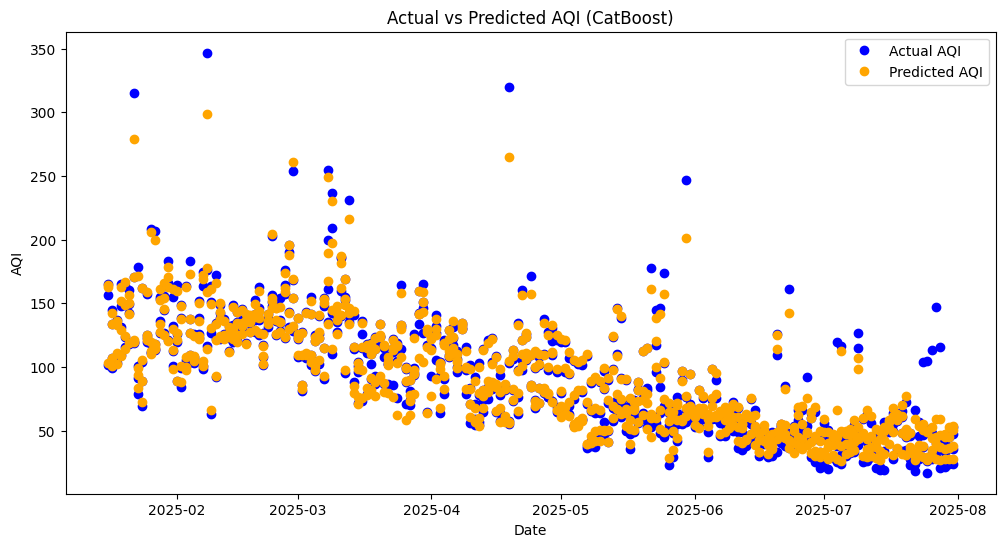

In [59]:
%pip install catboost
from catboost import CatBoostRegressor

# Model 7: CatBoost
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=10,
    loss_function='RMSE',
    verbose=0,
    random_seed=42
)

cat_model.fit(X_train_scaled1, y_train_scaled1.ravel())

pred_scaled = cat_model.predict(X_test_scaled1)
pred_cat = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

evaluate_model("CatBoost", pred_cat, y_test, y_test.index)
